# Customer Segmentation Using Clustering Techniques

The objective is to identify distinct customer segments based on demographic and behavioral characteristics and explore how these segments could support more targeted customer engagement in a banking context.

In [ ]:
!pip install hdbscan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.decomposition import PCA



In [ ]:
df=pd.read_csv('/content/customer_segmentation_data.csv')

## Data Understanding and Preparation

The dataset was reviewed to understand its structure, data types, and quality. Missing values and duplicate records were checked before applying clustering.

In [ ]:
df.head(4)

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   object 
 3   income                1000 non-null   int64  
 4   spending_score        1000 non-null   int64  
 5   membership_years      1000 non-null   int64  
 6   purchase_frequency    1000 non-null   int64  
 7   preferred_category    1000 non-null   object 
 8   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(6), object(2)
memory usage: 70.4+ KB


In [ ]:
df.isnull().sum()

,0
id,0
age,0
gender,0
income,0
spending_score,0
membership_years,0
purchase_frequency,0
preferred_category,0
last_purchase_amount,0


In [ ]:
df.columns

Index(['id', 'age', 'gender', 'income', 'spending_score', 'membership_years',
       'purchase_frequency', 'preferred_category', 'last_purchase_amount'],
      dtype='object')

In [ ]:
df.shape

(1000, 9)

In [ ]:
df.describe()

,id,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,43.783000,88500.800000,50.685000,5.46900,26.596000,492.348670
std,288.819436,15.042213,34230.771122,28.955175,2.85573,14.243654,295.744253
min,1.000000,18.000000,30004.000000,1.000000,1.00000,1.000000,10.400000
25%,250.750000,30.000000,57911.750000,26.000000,3.00000,15.000000,218.762500
50%,500.500000,45.000000,87845.500000,50.000000,5.00000,27.000000,491.595000
75%,750.250000,57.000000,116110.250000,76.000000,8.00000,39.000000,747.170000
max,1000.000000,69.000000,149973.000000,100.000000,10.00000,50.000000,999.740000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['gender'].value_counts()

,count
gender,
Male,357
Other,327
Female,316


In [ ]:
df['preferred_category'].value_counts()

,count
preferred_category,
Electronics,215
Sports,210
Home & Garden,206
Groceries,199
Clothing,170


No missing values or duplicate records were identified therefore, no additional cleaning was required.

## Feature Selection
Six numerical features were selected to represent both customer demographics and purchasing behavior: age, income, spending score, membership years, purchase frequency, and last purchase amount. Identifier variables were excluded because they do not describe customer characteristics.

In [ ]:
features=['age',
    'income',
    'spending_score',
    'membership_years',
    'purchase_frequency',
    'last_purchase_amount'

]
x=df[features]

## Feature Scaling

The selected features were standardized using StandardScaler. This is necessary because K-Means, DBSCAN, and HDBSCAN are distance based clustering methods and the variables have different scales.

In [ ]:
scaler= StandardScaler()
x_scaled=scaler.fit_transform(x)

In [ ]:
x_scaled[:5]

array([[-0.38464377,  0.31686767,  1.35846776, -0.86501013, -0.18234781,
        -1.28154045],
       [-1.51536211, -0.28201608,  0.32186512, -1.2153585 ,  1.08200524,
        -1.52376266],
       [ 1.07863878,  1.11277804, -0.71473752, -1.2153585 ,  0.09861954,
        -0.23000511],
       [-0.25161809, -1.21009592,  0.80561302,  1.2370801 , -1.51694269,
         1.69007953],
       [ 1.411203  ,  1.52337438, -1.02571832, -0.86501013, -0.11210597,
        -0.49144272]])

## Selecting the Number of Clusters

In [ ]:
#finding wcss value for different number of clusters
wcss=[]
for i in range(1,11):
   kmeans=KMeans(n_clusters=i,init='k-means++',random_state=40)
   kmeans.fit(x_scaled)
   wcss.append(kmeans.inertia_)

### **Elbow Point Graph** to decide number of clusters

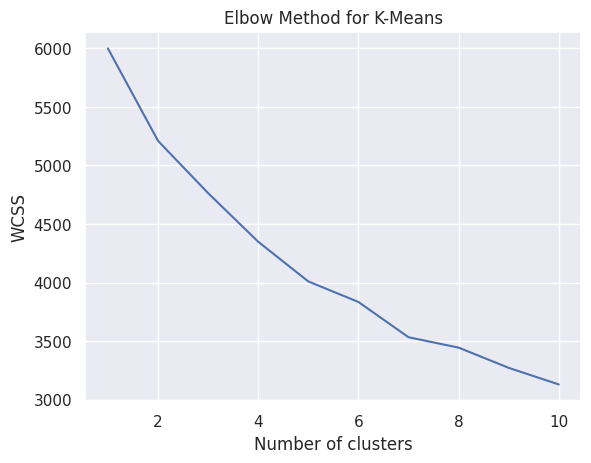

In [ ]:
sns.set()
plt.plot(range(1,11),wcss)
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

### Silhouette Score

In [ ]:
for k in [3, 5, 7, 9, 11]:
    kmeans = KMeans(n_clusters=k, random_state=40)
    labels = kmeans.fit_predict(x_scaled)

    score = silhouette_score(x_scaled, labels)

    print(k, score)

3 0.11568056418804676
5 0.1286515119566343
7 0.13903728865476064
9 0.13325151752116846
11 0.13797299918846187


Based on the Elbow Method and Silhouette Score K=7 was selected as a suitable number of clusters. The decrease in WCSS becomes less significant after this point, and K=7 achieved the highest Silhouette Score (0.139) among the tested values.

# Final K-Means Model

In [ ]:
kmeans = KMeans(
    n_clusters=7,
    init='k-means++',
    random_state=40,
    n_init=10
)

df['clusters'] = kmeans.fit_predict(x_scaled)

kmeans_score = silhouette_score(x_scaled, df['clusters'])
print(f'K-Means Silhouette Score: {kmeans_score:.3f}')


K-Means Silhouette Score: 0.139


### Visualizing K-Means Clusters

PCA was used to reduce the six standardized features into two components for visualization. This plot is a simplified two dimensional view of the clusters the K-Means model itself was built using all six features.

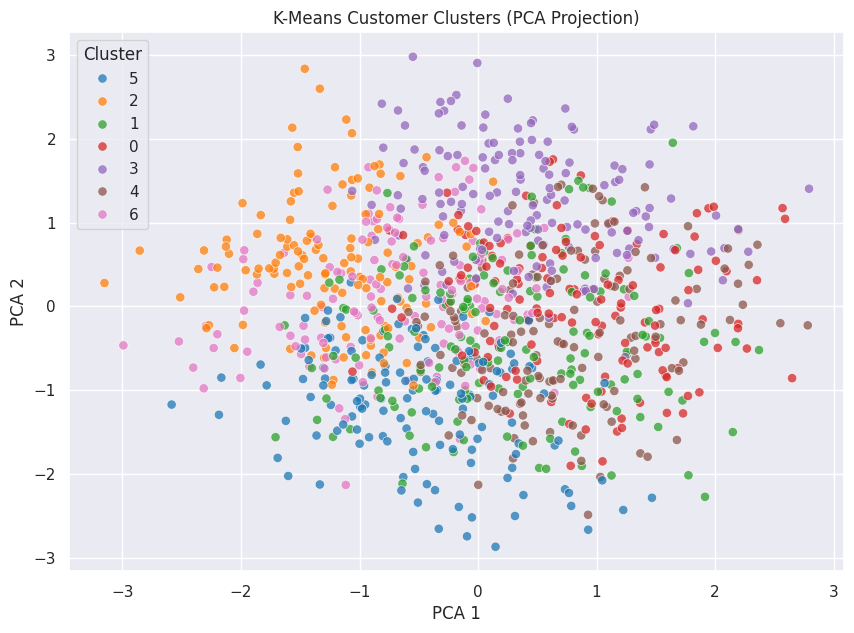

In [ ]:
pca = PCA(n_components=2, random_state=40)
X_pca = pca.fit_transform(x_scaled)

plot_df = pd.DataFrame({
    'PCA 1': X_pca[:, 0],
    'PCA 2': X_pca[:, 1],
    'Cluster': df['clusters'].astype(str)
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x='PCA 1',
    y='PCA 2',
    hue='Cluster',
    palette='tab10',
    alpha=0.75,
    s=45
)

plt.title('K-Means Customer Clusters (PCA Projection)')
plt.legend(title='Cluster')
plt.show()

### Cluster Sizes

In [ ]:
df['clusters'].value_counts().sort_index()

,count
clusters,
0,142
1,154
2,136
3,151
4,143
5,139
6,135


## Customer Segment Profiling

The average values of the selected features were calculated for each cluster to identify the demographic and behavioral characteristics of each customer segment.

In [ ]:
df.groupby('clusters')[features].mean().round(2)

,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
clusters,,,,,,
0,47.08,113857.71,67.50,7.94,32.68,746.50
1,40.43,64207.31,70.66,7.38,17.85,299.21
2,58.00,115147.42,39.13,4.00,15.90,380.32
3,53.40,57879.48,54.59,3.50,30.28,730.26
4,44.73,72885.50,21.06,7.59,35.74,404.27
5,34.81,111579.33,60.60,3.81,37.22,241.10
6,27.30,89726.50,38.65,3.83,16.19,644.08


## DBSCAN Clustering

DBSCAN was tested as an alternative density based clustering method. Different values of eps were evaluated while keeping min_samples fixed at 3.

In [ ]:
for eps in [1.10, 1.12, 1.14, 1.16, 1.18, 1.20, 1.22]:
    dbscan = DBSCAN(eps=eps, min_samples=3)
    labels = dbscan.fit_predict(x_scaled)

    mask = labels != -1

    if len(set(labels[mask])) > 1:
        score = silhouette_score(x_scaled[mask], labels[mask])

        print(
            "eps =", eps,
            "| clusters =", len(set(labels[mask])),
            "| noise =", sum(labels == -1),
            "| silhouette =", score
        )

eps = 1.1 | clusters = 11 | noise = 145 | silhouette = -0.2536421645396653
eps = 1.12 | clusters = 6 | noise = 129 | silhouette = -0.2043905771411999
eps = 1.14 | clusters = 2 | noise = 113 | silhouette = 0.08468182169221176
eps = 1.16 | clusters = 2 | noise = 88 | silhouette = 0.0830358121245432
eps = 1.18 | clusters = 2 | noise = 76 | silhouette = 0.08111486808754531
eps = 1.2 | clusters = 2 | noise = 62 | silhouette = 0.08011973937801467


Among the tested settings, DBSCAN produced only two clusters with low Silhouette Scores. Increasing eps reduced the number of noise observations but did not substantially improve cluster separation.

In [ ]:
dbscan = DBSCAN(eps=1.20, min_samples=3)
y_dbscan = dbscan.fit_predict(x_scaled)

n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise = (y_dbscan == -1).sum()

mask = y_dbscan != -1
dbscan_score = silhouette_score(x_scaled[mask], y_dbscan[mask])

print(f'Clusters: {n_clusters}')
print(f'Noise points: {n_noise}')
print(f'Silhouette Score: {dbscan_score:.3f}')

Clusters: 2
Noise points: 62
Silhouette Score: 0.080


The final DBSCAN configuration produced two clusters, 62 noise observations, and a Silhouette Score of approximately 0.080. This indicates weak cluster separation therefore, DBSCAN was not selected as the final model.

## HDBSCAN Clustering
HDBSCAN was evaluated as an additional density based clustering method. Unlike K-Means it does not require specifying the number of clusters in advance and can classify observations as noise.

In [ ]:
hdbscan_model=hdbscan.HDBSCAN(min_cluster_size=20, min_samples=5)
y_hdbscan=hdbscan_model.fit_predict(x_scaled)

In [ ]:
n_clusters=len(set(y_hdbscan))-(1 if -1 in y_hdbscan else 0)
n_noise = sum(y_hdbscan == -1)

print("Clusters =",n_clusters)
print("Noise =",n_noise)

Clusters = 2
Noise = 766


In [ ]:
mask=y_hdbscan!=-1

score = silhouette_score(
    x_scaled[mask],
    y_hdbscan[mask]
)

print("Silhouette=", score)

Silhouette= 0.11889971093655903


HDBSCAN identified two clusters but classified 766 out of 1,000 customers (76.6%) as noise. Although the Silhouette Score for the non noise observations was 0.119, the low customer coverage makes HDBSCAN unsuitable as the final segmentation model.

## Model Comparison

| Model | Number of Clusters | Noise Points | Silhouette Score | Decision |
|---|---:|---:|---:|---|
| K-Means | 7 | 0 | 0.139 | Selected final model |
| DBSCAN | 2 | 62 | 0.080 | Not selected |
| HDBSCAN | 2 | 766 | 0.119* | Not selected |

The HDBSCAN Silhouette Score was calculated using non noise observations only.

**K-Means was selected as the final model** because it assigned every customer to a segment and produced the most useful and interpretable result for this project.

## Customer Segment Summary



*   Cluster 0: High income customers with high spending, high purchase
frequency, and high last purchase amounts
*   Cluster 1: Lower income customers with high spending scores but relatively lower purchase frequency

*   Cluster 2: Older, high income customers with relatively low spending and purchase frequency
*   Cluster 3: Lower income customers with moderate spending and high purchase frequency and last purchase amounts

*   Cluster 4: Customers with relatively low spending but very high purchase frequency
*   Cluster 5: Younger, high income customers with high spending and the highest purchase frequency

*   Cluster 6: Younger customers with moderate income and spending, lower purchase frequency, but relatively high last purchase amounts












These profiles show that the K-Means clusters represent customers with different demographic and purchasing characteristics. The cluster labels are descriptive summaries rather than fixed customer categories.